#### Importing the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
input_data_folder = "../data/raw/nass-usda-bee-colony-2015-2025"
raw_data_file = f"{input_data_folder}/F5B59C51-6C83-3F5B-8117-CD7D3D157B1C.csv"

In [3]:
bee_df = pd.read_csv(raw_data_file)
bee_df = bee_df.dropna(axis=1) # Drop columns with all NaN values

In [4]:
bee_df.head()

,Program,Year,Period,Geo Level,State,watershed_code,Commodity,Data Item,Domain,Domain Category,Value
0,SURVEY,2025,APR THRU JUN,NATIONAL,US TOTAL,0,HONEY,"HONEY, BEE COLONIES - ADDED & REPLACED, MEASUR...",TOTAL,NOT SPECIFIED,"641,610"
1,SURVEY,2025,APR THRU JUN,NATIONAL,US TOTAL,0,HONEY,"HONEY, BEE COLONIES - LOSS, COLONY COLLAPSE DI...",TOTAL,NOT SPECIFIED,"60,480"
2,SURVEY,2025,APR THRU JUN,NATIONAL,US TOTAL,0,HONEY,"HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED ...",TOTAL,NOT SPECIFIED,"292,630"
3,SURVEY,2025,APR THRU JUN,NATIONAL,US TOTAL,0,HONEY,"HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED ...",TOTAL,NOT SPECIFIED,10
4,SURVEY,2025,APR THRU JUN,NATIONAL,US TOTAL,0,HONEY,"HONEY, BEE COLONIES, AFFECTED BY DISEASE - INV...",TOTAL,NOT SPECIFIED,4.1


#### Printing out the desciprtion of our dataframe

In [5]:
bee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25347 entries, 0 to 25346
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Program          25347 non-null  object
 1   Year             25347 non-null  int64 
 2   Period           25347 non-null  object
 3   Geo Level        25347 non-null  object
 4   State            25347 non-null  object
 5   watershed_code   25347 non-null  int64 
 6   Commodity        25347 non-null  object
 7   Data Item        25347 non-null  object
 8   Domain           25347 non-null  object
 9   Domain Category  25347 non-null  object
 10  Value            25347 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.1+ MB


#### Removing rows older than 2015 as they do not contain sufficient information for our task

In [6]:
bee_df = bee_df[bee_df["Year"] >= 2015]
bee_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24087 entries, 0 to 24086
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Program          24087 non-null  object
 1   Year             24087 non-null  int64 
 2   Period           24087 non-null  object
 3   Geo Level        24087 non-null  object
 4   State            24087 non-null  object
 5   watershed_code   24087 non-null  int64 
 6   Commodity        24087 non-null  object
 7   Data Item        24087 non-null  object
 8   Domain           24087 non-null  object
 9   Domain Category  24087 non-null  object
 10  Value            24087 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.2+ MB


#### Inspecting the columns

Some columns like watershed_code, commodity, domain, domain category, in the above data seem like they do not contain additional information across various states and years (rows). We may as well remove them. However, let us make sure of this below. 

<Axes: title={'center': 'Watershed_code Distribution'}, xlabel='watershed_code'>

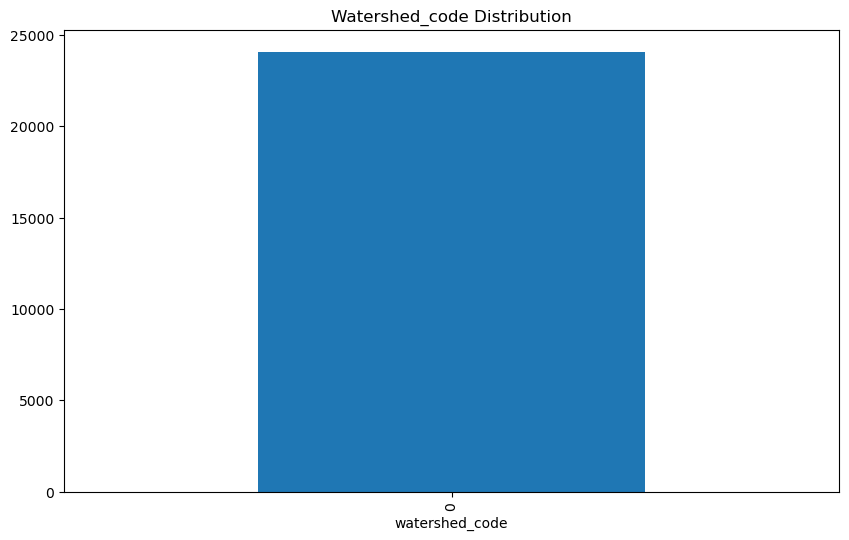

In [7]:
bee_df["watershed_code"].value_counts().plot(kind='bar', title='Watershed_code Distribution', figsize=(10, 6))

<Axes: title={'center': 'Unique Value Counts for Commodity'}, xlabel='Commodity'>

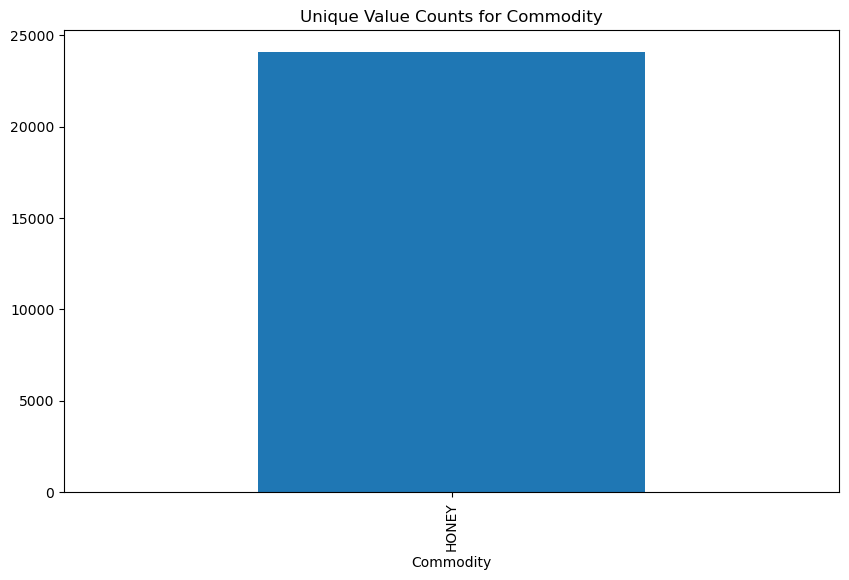

In [8]:
bee_df["Commodity"].value_counts().plot(kind='bar', title='Unique Value Counts for Commodity', figsize=(10, 6))

<Axes: title={'center': 'Domain Distribution'}, xlabel='Domain'>

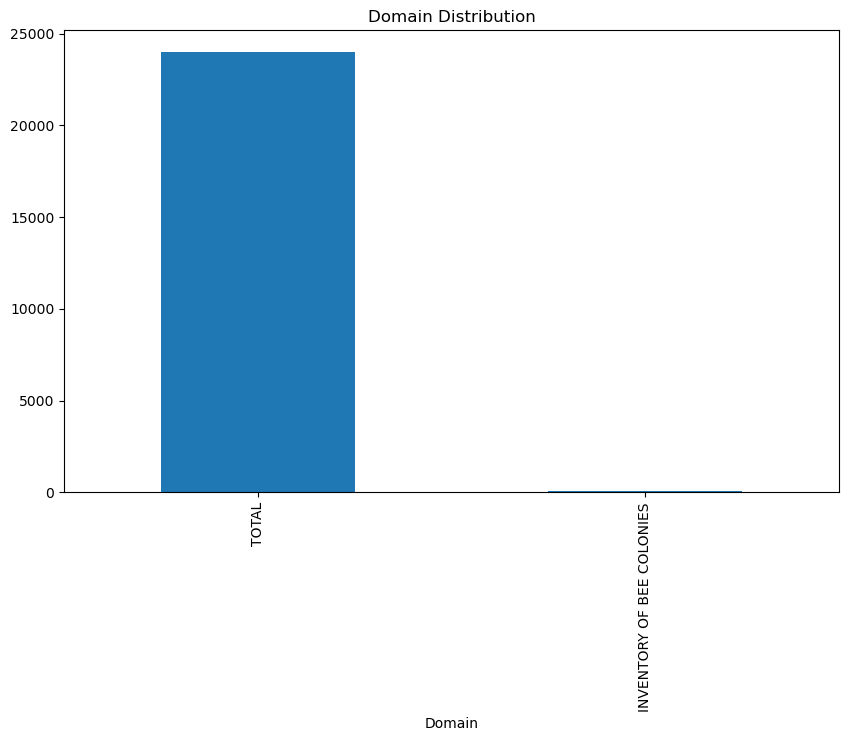

In [9]:
bee_df["Domain"].value_counts().plot(kind='bar', title='Domain Distribution', figsize=(10, 6))

<Axes: title={'center': 'Domain Category Distribution'}, xlabel='Domain Category'>

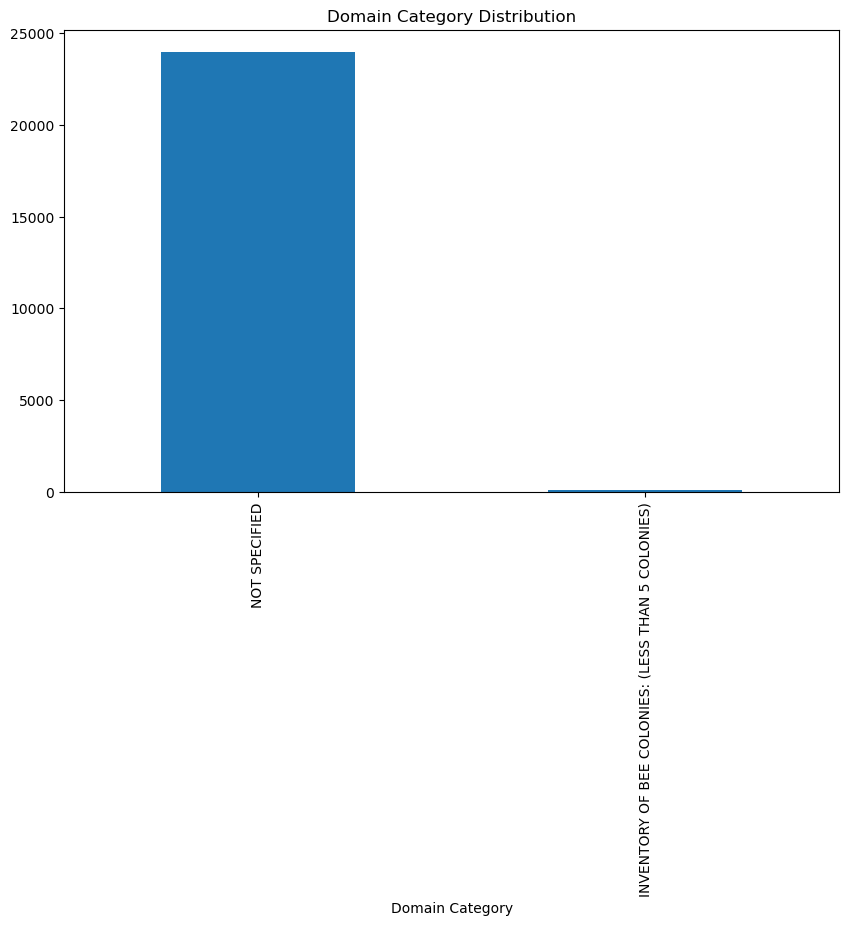

In [10]:
bee_df["Domain Category"].value_counts().plot(kind='bar', title='Domain Category Distribution', figsize=(10, 6))

<Axes: title={'center': 'Program Distribution'}, xlabel='Program'>

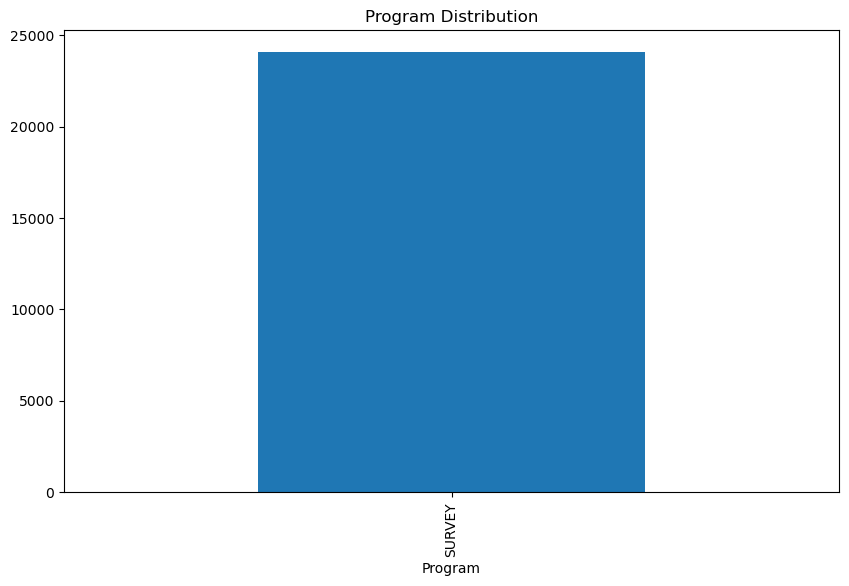

In [11]:
bee_df["Program"].value_counts().plot(kind='bar', title='Program Distribution', figsize=(10, 6))    

As we can witness above, we verify our initial claim. We will remove these columns below

In [12]:
columns_to_drop = ['watershed_code', 'Commodity', 'Domain', 'Domain Category','Program']
bee_df_new = bee_df.drop(columns=columns_to_drop, axis=1)
bee_df_new.head()

,Year,Period,Geo Level,State,Data Item,Value
0,2025,APR THRU JUN,NATIONAL,US TOTAL,"HONEY, BEE COLONIES - ADDED & REPLACED, MEASUR...","641,610"
1,2025,APR THRU JUN,NATIONAL,US TOTAL,"HONEY, BEE COLONIES - LOSS, COLONY COLLAPSE DI...","60,480"
2,2025,APR THRU JUN,NATIONAL,US TOTAL,"HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED ...","292,630"
3,2025,APR THRU JUN,NATIONAL,US TOTAL,"HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED ...",10
4,2025,APR THRU JUN,NATIONAL,US TOTAL,"HONEY, BEE COLONIES, AFFECTED BY DISEASE - INV...",4.1


In [13]:
# Print number of states 
print(f"Number of unique states (including US TOTAL): {bee_df_new['State'].nunique()}")

Number of unique states (including US TOTAL): 47


<Axes: title={'center': 'State Distribution'}, xlabel='Geo Level'>

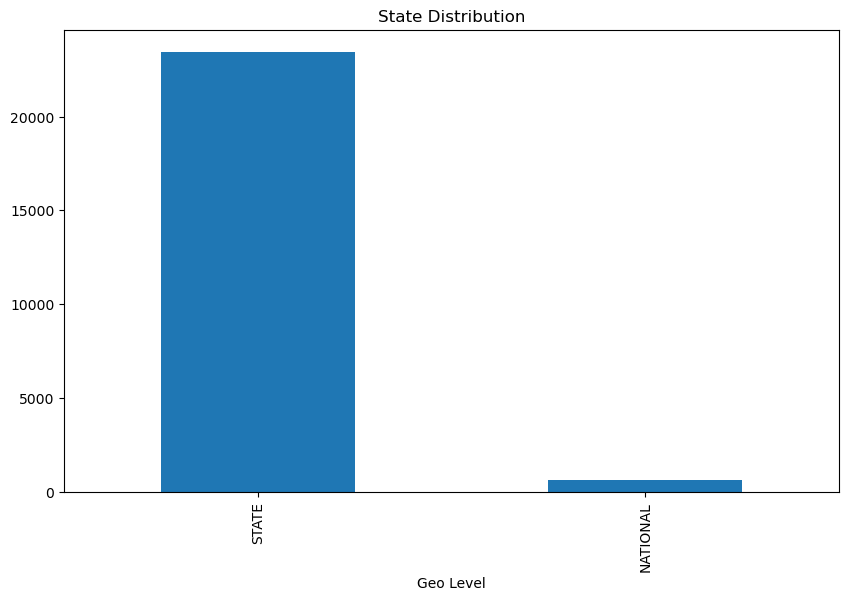

In [14]:
bee_df_new["Geo Level"].value_counts().plot(kind='bar', title='State Distribution', figsize=(10, 6))

In [15]:
# Verify that the number of NATIONAL entries in Geo Level matches the number of US TOTAL entries in State
bee_df_new["Geo Level"].value_counts()["NATIONAL"] == bee_df_new["State"].value_counts()["US TOTAL"]    

np.True_

In [16]:
# Remove the Geo Level column as well
bee_df_new = bee_df_new.drop(columns="Geo Level", axis=1)

<Axes: title={'center': 'Period Distribution'}, xlabel='Period'>

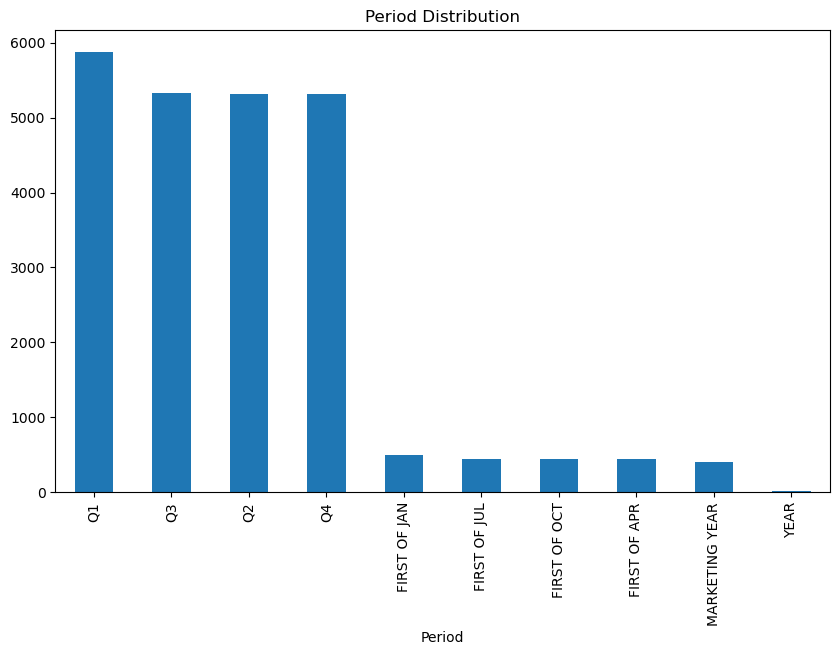

In [17]:
bee_df_new.loc[bee_df_new["Period"] == "JAN THRU MAR", "Period"] = "Q1"
bee_df_new.loc[bee_df_new["Period"] == "APR THRU JUN", "Period"] = "Q2"
bee_df_new.loc[bee_df_new["Period"] == "JUL THRU SEP", "Period"] = "Q3"
bee_df_new.loc[bee_df_new["Period"] == "OCT THRU DEC", "Period"] = "Q4"

bee_df_new["Period"].value_counts().plot(kind='bar', title='Period Distribution', figsize=(10, 6))  

There are a lot more than just quarterly data. We have to figure out what to do with this. Maybe could we use this as test? 

In [18]:
bee_df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24087 entries, 0 to 24086
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Year       24087 non-null  int64 
 1   Period     24087 non-null  object
 2   State      24087 non-null  object
 3   Data Item  24087 non-null  object
 4   Value      24087 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.1+ MB


**Key observation:** I expect that the Value column should be of data type float assuming it contains the data in numerical values. Since the data type is of object, I suspect something fishy is going on. My speculation is that there are some missing values. Let us get back to this later. For now, I want to change some of the rows to be columns. 

In [19]:
bee_df_new.head(12)

,Year,Period,State,Data Item,Value
0,2025,Q2,US TOTAL,"HONEY, BEE COLONIES - ADDED & REPLACED, MEASUR...","641,610"
1,2025,Q2,US TOTAL,"HONEY, BEE COLONIES - LOSS, COLONY COLLAPSE DI...","60,480"
2,2025,Q2,US TOTAL,"HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED ...","292,630"
3,2025,Q2,US TOTAL,"HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED ...",10
4,2025,Q2,US TOTAL,"HONEY, BEE COLONIES, AFFECTED BY DISEASE - INV...",4.1
5,2025,Q2,US TOTAL,"HONEY, BEE COLONIES, AFFECTED BY OTHER CAUSES ...",5.8
6,2025,Q2,US TOTAL,"HONEY, BEE COLONIES, AFFECTED BY PESTICIDES - ...",7.1
7,2025,Q2,US TOTAL,"HONEY, BEE COLONIES, AFFECTED BY PESTS ((EXCL ...",10.7
8,2025,Q2,US TOTAL,"HONEY, BEE COLONIES, AFFECTED BY UNKNOWN CAUSE...",3.1
9,2025,Q2,US TOTAL,"HONEY, BEE COLONIES, AFFECTED BY VARROA MITES ...",27.3


In [20]:
# Pivot the DataFrame to make 'Data Item' values into new columns
bee_df_wide = bee_df_new.pivot_table(
    index=['Year', 'Period', 'State'], 
    columns='Data Item', 
    values='Value',
    aggfunc='sum'
).reset_index()

bee_df_wide.tail(12)

Data Item,Year,Period,State,"HONEY, BEE COLONIES - ADDED & REPLACED, MEASURED IN COLONIES","HONEY, BEE COLONIES - INVENTORY, MAX, MEASURED IN COLONIES","HONEY, BEE COLONIES - INVENTORY, MEASURED IN COLONIES","HONEY, BEE COLONIES - LOSS, COLONY COLLAPSE DISORDER, MEASURED IN COLONIES","HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN COLONIES","HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY DISEASE - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY OTHER CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY PESTICIDES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY PESTS ((EXCL VARROA MITES)) - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY PESTS (EXCL VARROA MITES) - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY UNKNOWN CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY VARROA MITES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, RENOVATED - INVENTORY, MEASURED IN COLONIES","HONEY, BEE COLONIES, RENOVATED - INVENTORY, MEASURED IN PCT OF COLONIES"
4023,2025,Q2,NEW YORK,"14,000","53,000",NaN,NaN,"2,000",4,0.8,2.4,(Z),2.1,NaN,1,14.7,"3,900",7
4024,2025,Q2,NORTH CAROLINA,"6,500","27,000",NaN,NaN,"2,300",9,0.6,2,0.7,6.9,NaN,1.6,26.3,"3,500",13
4025,2025,Q2,NORTH DAKOTA,"12,000","395,000",NaN,NaN,"13,000",3,3.5,1.2,10.6,22.3,NaN,1.4,36.8,"21,000",5
4026,2025,Q2,OHIO,"8,500","25,000",NaN,NaN,"2,200",9,1.7,13.6,7,17.7,NaN,2.4,39.3,"4,900",20
4027,2025,Q2,OREGON,"27,000","106,000",NaN,NaN,"5,500",5,6.6,13.8,10.7,(Z),NaN,1,10.2,"14,500",14
4028,2025,Q2,OTHER STATES,"137,910","363,840",NaN,NaN,"32,200",9,5.1,5.7,7.6,8,NaN,4.9,38.8,"51,190",14
4029,2025,Q2,PENNSYLVANIA,"8,500","30,000",NaN,NaN,930,3,1.1,3.4,(Z),9.9,NaN,2,44.1,"2,700",9
4030,2025,Q2,SOUTH DAKOTA,"2,600","220,000",NaN,NaN,"6,000",3,(Z),0,0,1.4,NaN,(Z),15,"11,000",5
4031,2025,Q2,TEXAS,"68,000","380,000",NaN,NaN,"23,000",6,7,2,6.8,8,NaN,4.8,17,"73,000",19
4032,2025,Q2,US TOTAL,"641,610",NaN,NaN,"60,480","292,630",10,4.1,5.8,7.1,10.7,NaN,3.1,27.3,"486,190",16


In [21]:
bee_df_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4035 entries, 0 to 4034
Data columns (total 18 columns):
 #   Column                                                                                                 Non-Null Count  Dtype 
---  ------                                                                                                 --------------  ----- 
 0   Year                                                                                                   4035 non-null   int64 
 1   Period                                                                                                 4035 non-null   object
 2   State                                                                                                  4035 non-null   object
 3   HONEY, BEE COLONIES - ADDED & REPLACED, MEASURED IN COLONIES                                           1817 non-null   object
 4   HONEY, BEE COLONIES - INVENTORY, MAX, MEASURED IN COLONIES                                            

In [22]:
bee_df_wide[bee_df_wide["HONEY, BEE COLONIES, AFFECTED BY PESTS (EXCL VARROA MITES) - INVENTORY, MEASURED IN PCT OF COLONIES"].notna()]

Data Item,Year,Period,State,"HONEY, BEE COLONIES - ADDED & REPLACED, MEASURED IN COLONIES","HONEY, BEE COLONIES - INVENTORY, MAX, MEASURED IN COLONIES","HONEY, BEE COLONIES - INVENTORY, MEASURED IN COLONIES","HONEY, BEE COLONIES - LOSS, COLONY COLLAPSE DISORDER, MEASURED IN COLONIES","HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN COLONIES","HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY DISEASE - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY OTHER CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY PESTICIDES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY PESTS ((EXCL VARROA MITES)) - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY PESTS (EXCL VARROA MITES) - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY UNKNOWN CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, AFFECTED BY VARROA MITES - INVENTORY, MEASURED IN PCT OF COLONIES","HONEY, BEE COLONIES, RENOVATED - INVENTORY, MEASURED IN COLONIES","HONEY, BEE COLONIES, RENOVATED - INVENTORY, MEASURED IN PCT OF COLONIES"
418,2015,YEAR,US TOTAL,NaN,NaN,NaN,"7,000",NaN,NaN,2.2,15.5,4.9,NaN,12.5,20.8,19.8,NaN,NaN
837,2016,YEAR,US TOTAL,NaN,NaN,NaN,"5,500",NaN,NaN,4.1,11.6,4.3,NaN,13.9,17.5,20.9,NaN,NaN
1256,2017,YEAR,US TOTAL,NaN,NaN,NaN,"6,000",NaN,NaN,0,13,5,NaN,18.2,22.2,26.3,NaN,NaN


In [23]:
bee_df_wide.to_csv("../data/interim/bee_df.csv", index=False)